# Weighting Evaluation

It had previously been discussed that evaluation of the produced mappings could prove tricky. There is no benchmark truth to test against, and similarity can be hard to define beyond intuitive feeling.


To this end, it was decided that a ground truth would be produced by inspecting triplets of tracks and judging which pair should be closer or rather scored more similar. This was accepted as ultimately the mapping aims to capture a feeling of similarity and so this vague idea of similarity which comes from human judgement can be a good source of truth. Note for this edge cases were skipped, and it was decided that triplets should only be accepted when it was obvious and clear that similarity between two and dissimilarity of the third was immediately obvious. The triplets were produced using src/evaluation/produce_evaluation_table.py.


Following on from the src/evaluation/perform_evaluation.py script, these triplets were used to evaluate against randomly sampled feature weightings as well as some bespoke chosen weights. The resulting accuracy scores and other descriptive performance metrics were saved with this notebook serving primarily as a space to analyse these scores.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

import sys
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.config.paths import PROCESSED_DATA_DIR

## Load and Transform Dataset

In [3]:
results_df = pd.read_parquet(PROCESSED_DATA_DIR / "weight_evaluation_limit_31034.parquet")

In [4]:
results_df.head()

,trial,accuracy,mean_margin,median_margin,std_margin,weight_stats,weight_chroma,weight_entropy,weight_rhythm,weight_structure,weight_melody,weight_low,weight_mid,weight_high
0,17317,0.731183,0.034551,0.036737,0.100688,4.281664,2.289318,2.132904,1.022343,2.365520,0.311634,3.689440,2.307508,4.813763
1,15478,0.731183,0.034447,0.028416,0.104870,2.737181,0.966805,1.175578,1.759720,2.610226,0.137518,3.636563,2.527760,4.809581
2,7580,0.720430,0.021509,0.026342,0.082190,2.653973,3.994508,0.241914,3.424328,2.060097,2.834000,4.126383,4.937328,4.978423
3,24751,0.720430,0.023905,0.031385,0.086312,0.000000,5.000000,0.000000,2.500000,2.500000,2.500000,5.000000,5.000000,5.000000
4,13761,0.720430,0.025219,0.030119,0.089170,1.357952,1.585443,2.315422,2.763654,2.182652,1.226514,3.995942,4.075793,4.976050


Evaluation was performed on two separate weight sets and as such these two sets are separated below. 

One set was produced using uniform random sampling between 0 and 5 taking 20000 samples whilst the other set was produced by taking all possible combinations of values for weights from (0, 2.5, 5). The uniform random sample was used as a main search of the weight space whilst the grid search approach was important to ensure scenarios where weights are at their lowest and highest are all explored.

In [5]:
weight_columns = [col for col in results_df.columns if col.startswith("weight_")]

gridsearch_mask = results_df[weight_columns].isin([0, 2.5, 5])
gridsearch_df = results_df[gridsearch_mask.all(axis=1)]
uniform_sampled_df = results_df[~gridsearch_mask.all(axis=1)]

results_df["sampling_strategy"] = np.where(gridsearch_mask.all(axis=1), "gridsearch", "uniform_sampled")

In [6]:
print(f"Total results df shape: {results_df.shape}")
print(f"Gridsearch df shape: {gridsearch_df.shape}")
print(f"Uniform sampled df shape: {uniform_sampled_df.shape}")

Total results df shape: (39683, 15)
Gridsearch df shape: (19683, 14)
Uniform sampled df shape: (20000, 14)


In [7]:
gridsearch_df.head()

,trial,accuracy,mean_margin,median_margin,std_margin,weight_stats,weight_chroma,weight_entropy,weight_rhythm,weight_structure,weight_melody,weight_low,weight_mid,weight_high
3,24751,0.72043,0.023905,0.031385,0.086312,0.0,5.0,0.0,2.5,2.5,2.5,5.0,5.0,5.0
5,28852,0.72043,0.032573,0.038464,0.096363,2.5,2.5,0.0,0.0,2.5,0.0,5.0,2.5,5.0
11,33955,0.72043,0.032894,0.038210,0.095671,5.0,0.0,2.5,0.0,2.5,0.0,5.0,2.5,5.0
12,39058,0.72043,0.032826,0.037001,0.094805,5.0,5.0,5.0,0.0,2.5,0.0,5.0,2.5,5.0
13,30583,0.72043,0.023794,0.029420,0.086088,2.5,2.5,5.0,2.5,2.5,2.5,5.0,5.0,5.0


In [8]:
uniform_sampled_df.head()

,trial,accuracy,mean_margin,median_margin,std_margin,weight_stats,weight_chroma,weight_entropy,weight_rhythm,weight_structure,weight_melody,weight_low,weight_mid,weight_high
0,17317,0.731183,0.034551,0.036737,0.100688,4.281664,2.289318,2.132904,1.022343,2.365520,0.311634,3.689440,2.307508,4.813763
1,15478,0.731183,0.034447,0.028416,0.104870,2.737181,0.966805,1.175578,1.759720,2.610226,0.137518,3.636563,2.527760,4.809581
2,7580,0.720430,0.021509,0.026342,0.082190,2.653973,3.994508,0.241914,3.424328,2.060097,2.834000,4.126383,4.937328,4.978423
4,13761,0.720430,0.025219,0.030119,0.089170,1.357952,1.585443,2.315422,2.763654,2.182652,1.226514,3.995942,4.075793,4.976050
6,15069,0.720430,0.023578,0.030896,0.085432,4.293898,4.506537,4.808094,0.493047,1.708720,1.703865,3.801475,4.252107,4.892406


## Feature Distributions

Distributions across the two sampling techniques are checked to observe indicator behaviour as well as ensure sampling technique was correct. 

As expected, uniform sampled weights provide equally distributed weights, and grid search was performed along the options provided. Indicators seem to be normally distributed with standard deviation on margin having a strong positive skew in both cases. It is perhaps also worth mentioning that the peaks of margin values are more pronounced for grid search weights and this is likely due to restricted choices for weights leading to fewer outcome values.


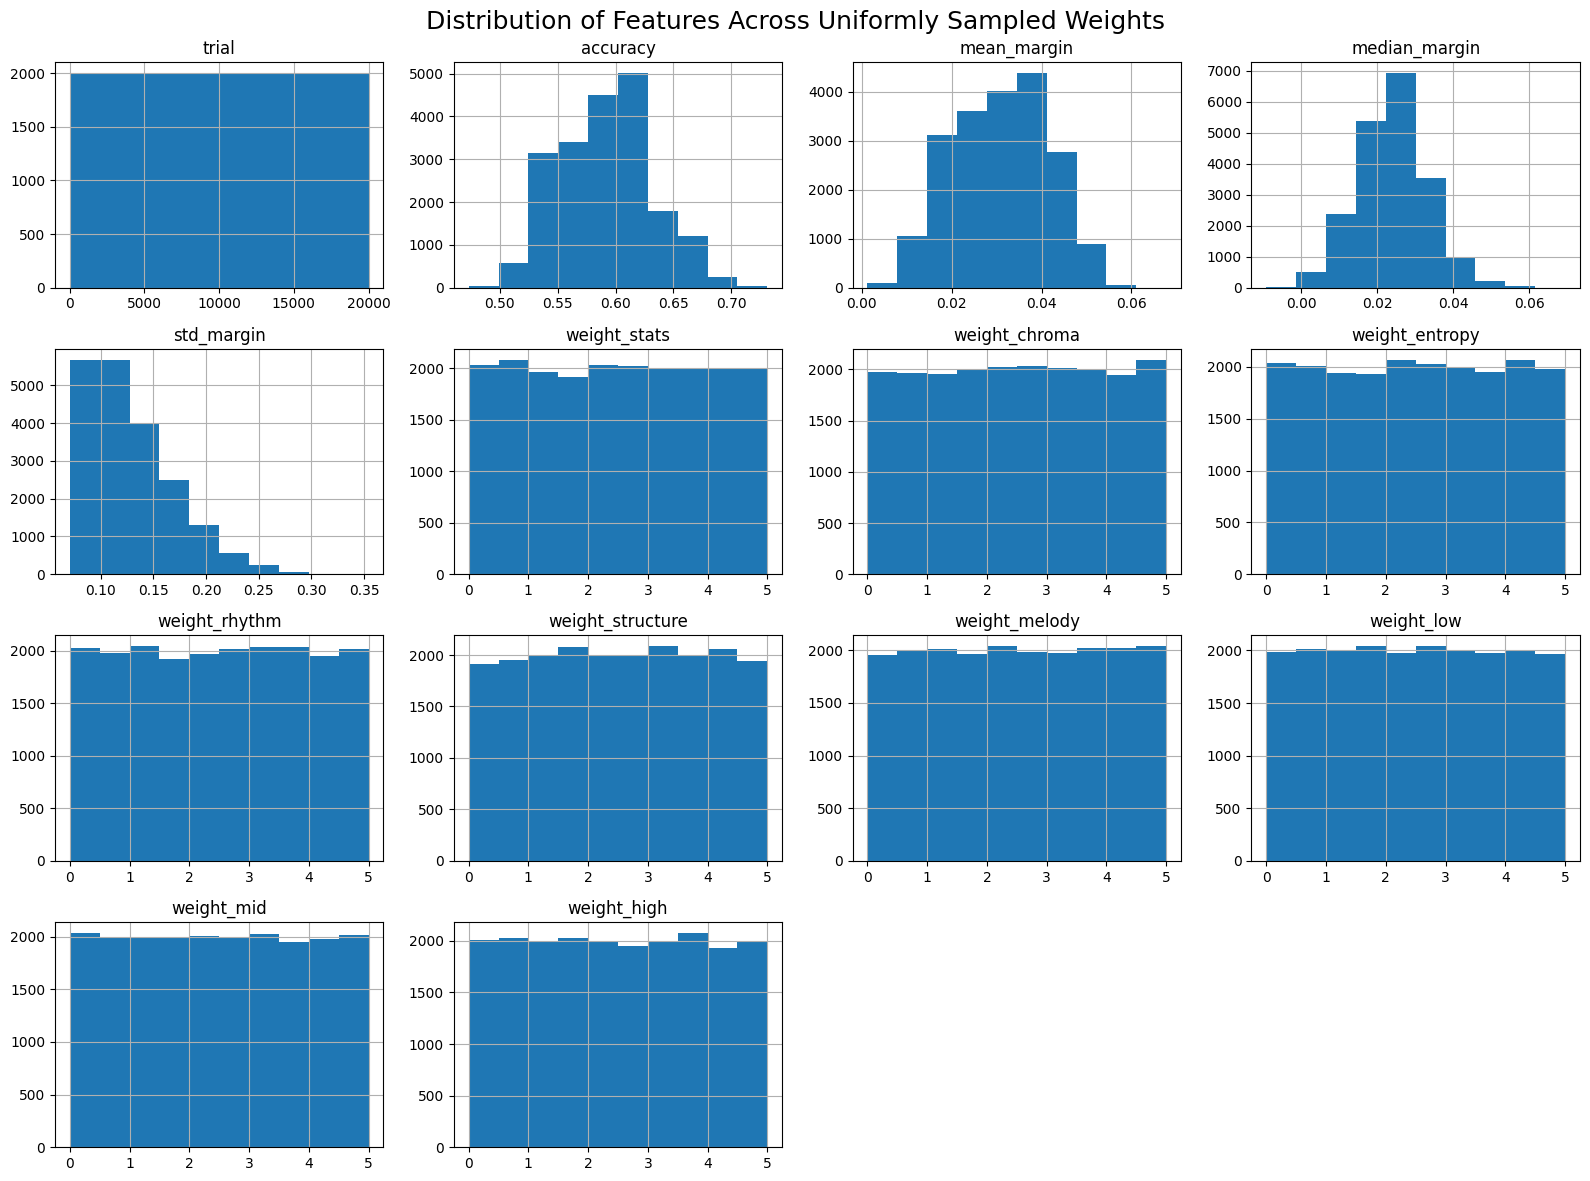

In [9]:
uniform_sampled_df.hist(
    bins=10,
    figsize=(16, 12),
    layout=(-1, 4)
)

plt.suptitle("Distribution of Features Across Uniformly Sampled Weights", fontsize=18)
plt.tight_layout()
plt.show()

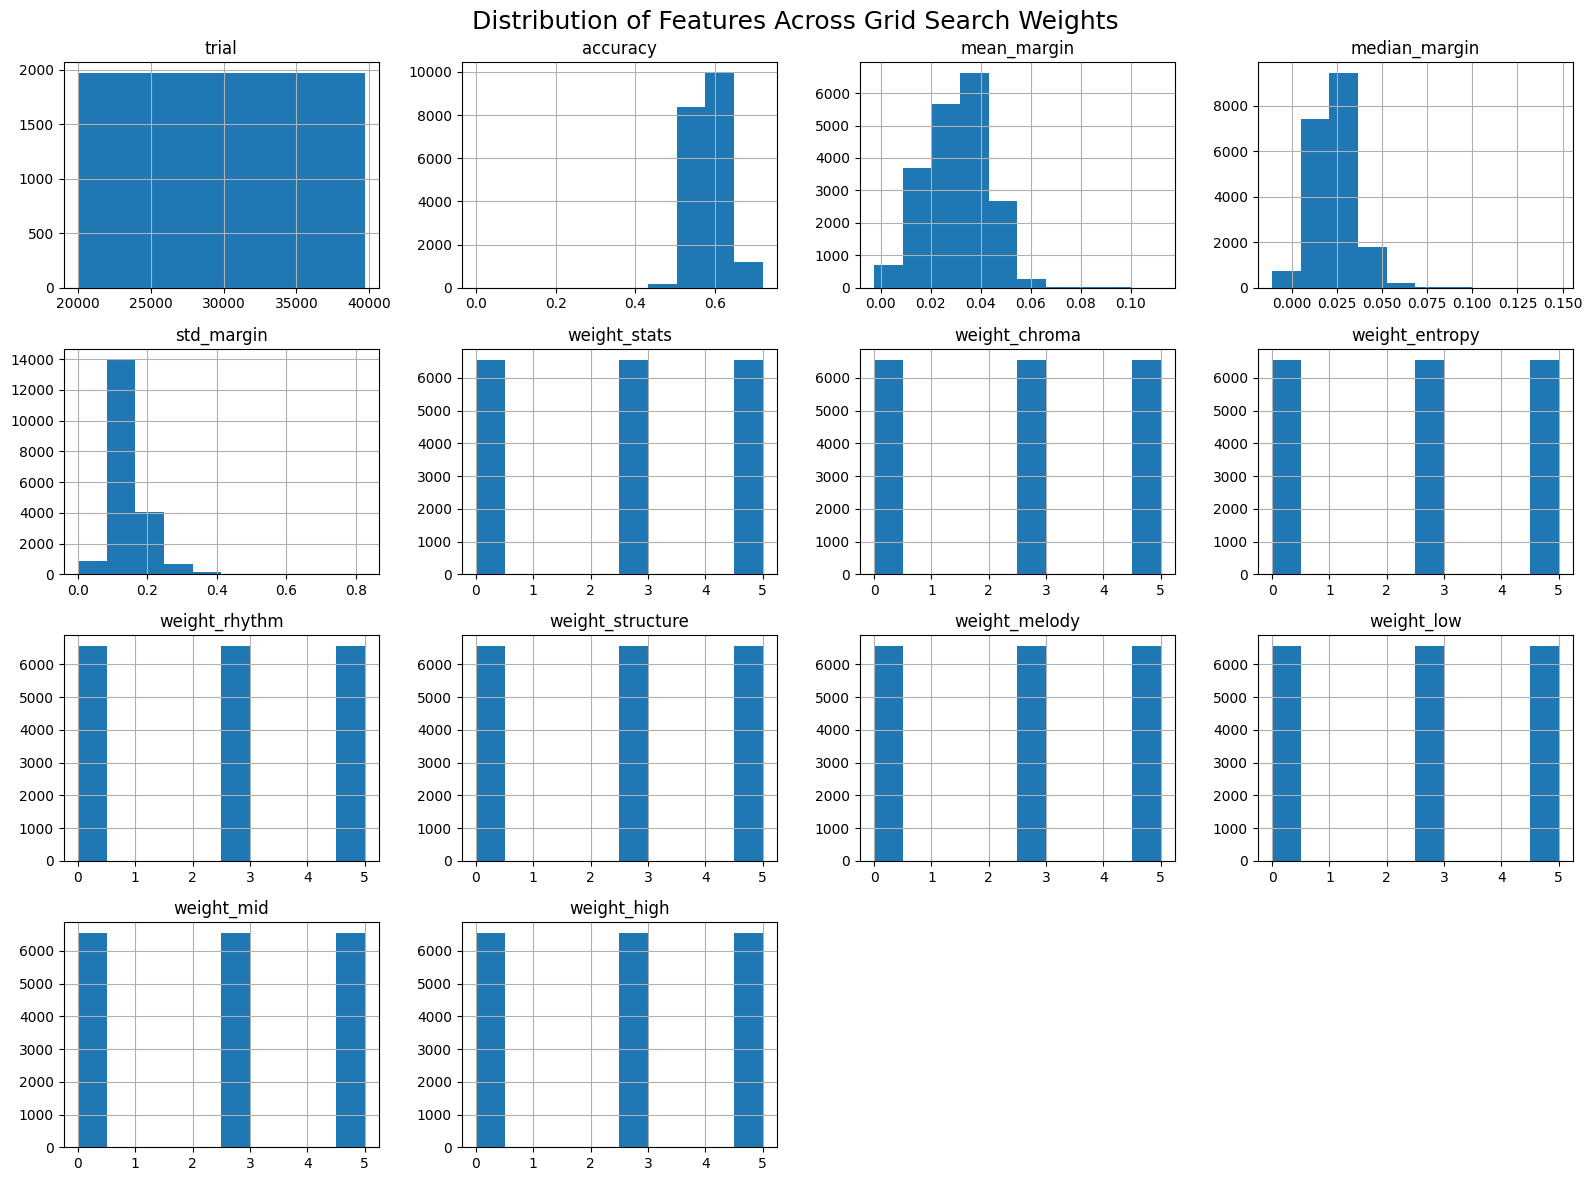

In [10]:
gridsearch_df.hist(
    bins=10,
    figsize=(16, 12),
    layout=(-1, 4)
)

plt.suptitle("Distribution of Features Across Grid Search Weights", fontsize=18)
plt.tight_layout()
plt.show()

After an initial overview of the simulation results, more insight is given next to scoring indicators.

## Score Distributions

Distribution of accuracy scores as well as other key indicators are checked across the two sampling techniques using boxplots. 

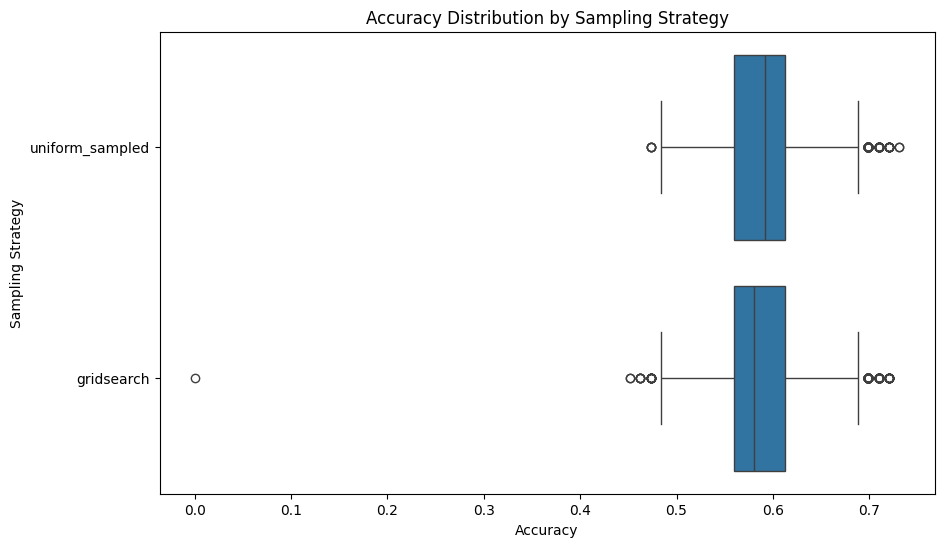

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="accuracy", y="sampling_strategy", data=results_df)
plt.xlabel("Accuracy")
plt.ylabel("Sampling Strategy")
plt.title("Accuracy Distribution by Sampling Strategy")
plt.show()


Accuracy scores seem to be more or less the same across the two sampling methods with one of the only differences being uniform sampling having a slightly higher median. Otherwise it can be seen that the inner quartile is between 0.55 and 0.62 roughly with highest scoring weights sitting outside the upper quartile just above 0.7. As analysis shifts towards selecting the most optimal weight configuration, focus will be directed towards the weights marked as upper outliers here.

Next, distributions are explored similarly for margin indicators. Here margin refers to the difference in cosine similarity between the desired closer and further pair. Though first, the 0 accuracy value is looked at quickly.


In [12]:
gridsearch_df[gridsearch_df["accuracy"] == 0.0]

,trial,accuracy,mean_margin,median_margin,std_margin,weight_stats,weight_chroma,weight_entropy,weight_rhythm,weight_structure,weight_melody,weight_low,weight_mid,weight_high
39682,20000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


On seeing that is row refers to the case where all weights are 0, this row is removed since it doesn’t serve any insight and will only cause to distort future plots.

In [13]:
gridsearch_df = gridsearch_df[gridsearch_df["accuracy"] != 0.0]
results_df = results_df[results_df["accuracy"] != 0.0]

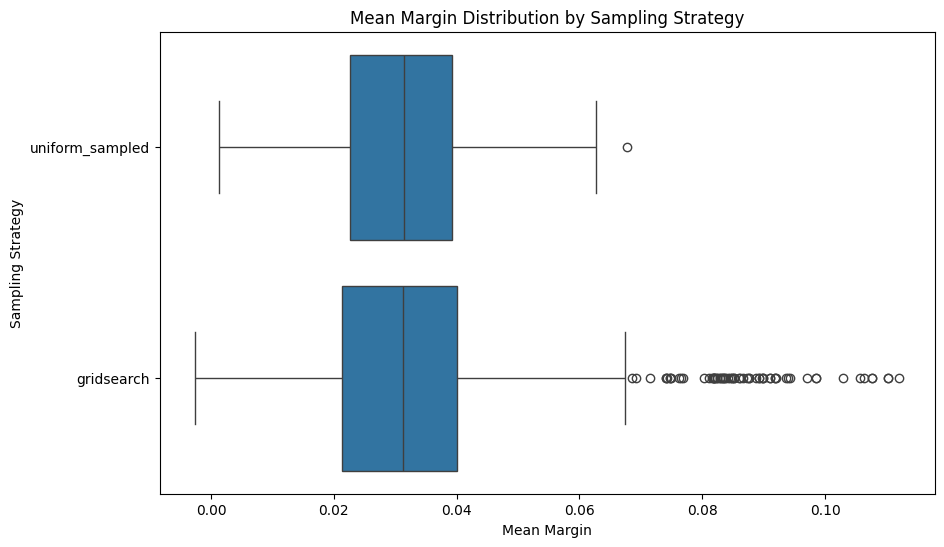

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="mean_margin", y="sampling_strategy", data=results_df)
plt.xlabel("Mean Margin")
plt.ylabel("Sampling Strategy")
plt.title("Mean Margin Distribution by Sampling Strategy")
plt.show()

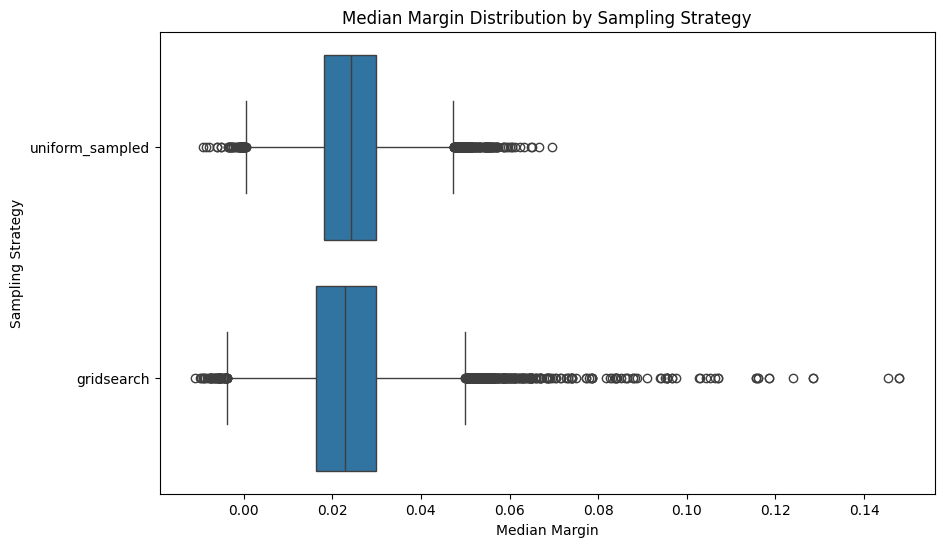

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="median_margin", y="sampling_strategy", data=results_df)
plt.xlabel("Median Margin")
plt.ylabel("Sampling Strategy")
plt.title("Median Margin Distribution by Sampling Strategy")
plt.show()

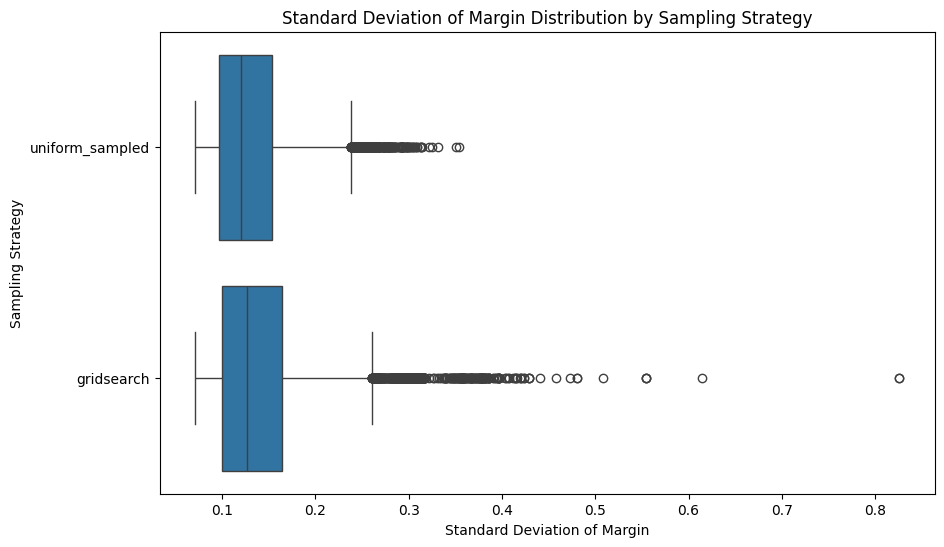

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="std_margin", y="sampling_strategy", data=results_df)
plt.xlabel("Standard Deviation of Margin")
plt.ylabel("Sampling Strategy")
plt.title("Standard Deviation of Margin Distribution by Sampling Strategy")
plt.show()

In [17]:
print("Number of standard deviations of margin outliers using IQR from uniform sampling:", ((uniform_sampled_df["std_margin"] > (uniform_sampled_df["std_margin"].quantile(0.75) + (uniform_sampled_df["std_margin"].quantile(0.75) - uniform_sampled_df["std_margin"].quantile(0.25))*1.5)) | (uniform_sampled_df["std_margin"] < (uniform_sampled_df["std_margin"].quantile(0.25) - (uniform_sampled_df["std_margin"].quantile(0.75) - uniform_sampled_df["std_margin"].quantile(0.25))*1.5))).sum())
print("Number of standard deviations of margin outliers using IQR from grid search:", ((gridsearch_df["std_margin"] > (gridsearch_df["std_margin"].quantile(0.75) + (gridsearch_df["std_margin"].quantile(0.75) - gridsearch_df["std_margin"].quantile(0.25))*1.5)) | (gridsearch_df["std_margin"] < (gridsearch_df["std_margin"].quantile(0.25) - (gridsearch_df["std_margin"].quantile(0.75) - gridsearch_df["std_margin"].quantile(0.25))*1.5))).sum())

Number of standard deviations of margin outliers using IQR from uniform sampling: 369
Number of standard deviations of margin outliers using IQR from grid search: 573


When discussing descriptive statistics for the margin values it should be remembered for clarity that these are already aggregated across the evaluation set for that weight configuration. Meaning, a median margin value for example indicates median margin levels for that weight configuration and not the median of all margins across the sample, that would instead be the median of the median margin levels. Unfortunately this is admittedly somewhat confusing but hopefully with special attention paid it should be navigable. 

From these plots it seems median and mean margin values are both on the whole below 0.1 with their median value being between 0.02 and 0.04 in both cases though a high outlier count should be noted. It should also be mentioned that the IQR is noticeably slim. 

Margin value standard deviations however are relatively large with median values around 0.13 and a large outlier count. This indicates a large variation of margin levels often occurs within configurations and unstable margins across the whole sample set. Further investigation will have to be performed on these indicators for the best performing configurations to gain an idea of stability.


## Weight Correlations

A correlation plot is produced to observe weight impacts on indicators.

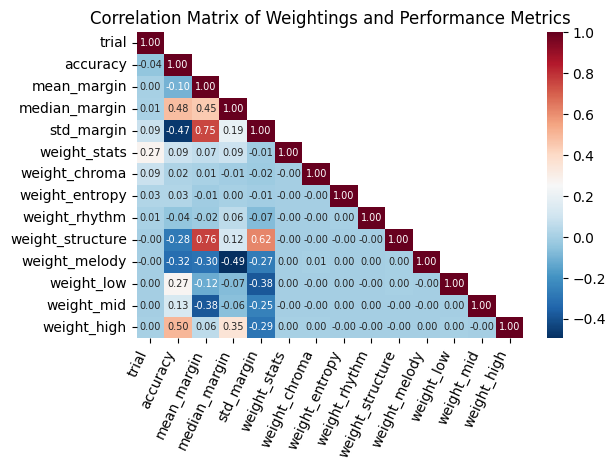

In [29]:
correlation_matrix = results_df.select_dtypes(include=[np.number]).corr()
upper_triangle_mask = np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)
correlation_matrix = correlation_matrix.mask(upper_triangle_mask)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    cmap="RdBu_r"
)

plt.xticks(rotation=65, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Matrix of Weightings and Performance Metrics")
plt.tight_layout()
plt.show()

As expected, correlations between the weights themselves is 0 since they were produced artificially. In fact: stats, chroma, entropy and rhythm weights seem to not correlate with any other feature. 

More importantly, correlations are present for indicators. It can be seen that margin spread is reduced by melody, low, mid and high register features whilst increased by structure features. This could suggest weighting structural features highly decreases the spread of cosine similarity scores. Also, spread on margin has a positive correlation with mean margin and also to a lesser extent with median margin. The difference in strength here make sense as the mean is affected by outlier values more than the median. These indicate that greater spread tends to have larger similarity difference gaps whilst being less accurate.

On accuracy, the register features all have positive correlations with high register being a standout at 0.5 whereas melody and structure correlate negatively with the indicator. These should be remembered when observing the best performing weight configurations. It’s also interesting to see median margin correlate well with accuracy whilst mean margin does not. This again is likely due to the mean being more susceptible to outlier values but also confirms that on average a larger difference in score will come with a more accurate similarity choice, which backs up intuitive ideas about similarity.

With this overview of the dataset, next focus is given to the best performing weight configurations.


## Examination of Best Weights

The top 100 performing weight configurations are used for examination.

In [45]:
weight_cols = [col for col in results_df.columns if col.startswith("weight_")]
best_weighting = results_df.loc[0, weight_cols].to_dict()

top_100_results = results_df.nlargest(100, "accuracy")

The histogram below shows a strong positive skew as is to be expected when examining ranked top scores.

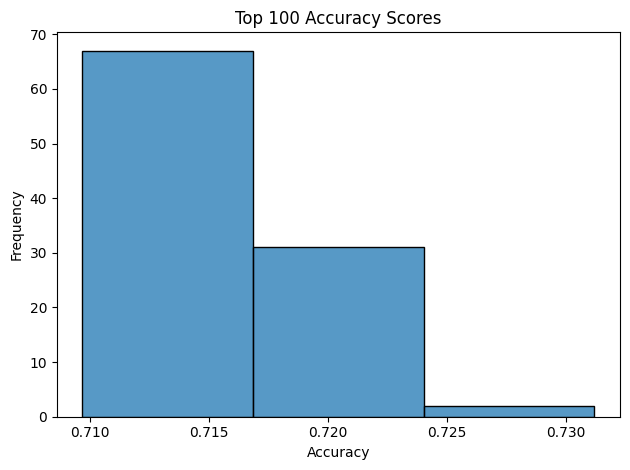

In [ ]:
sns.histplot(
    data=top_100_results,
    x="accuracy",
    bins=3,
)
plt.title("Top 100 Accuracy Scores")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [43]:
100/len(results_df)*100

0.25200342724661057

With the best 100 scores sitting between 0.71 and 0.73 roughly this gives a relatively low range of 0.02 though it should be remembered that the top 100 here only represents 0.25% of the simulated configurations. With this narrow gap in performance it is possible that there isn't one standout configuration. It should also be noted that with an accuracy scoring around 0.7 it is less obvious that overfitting may be occurring than if the score were higher whilst still showing a better performance than random choice.

It is also seen below that the two sampling techniques contribute roughly equally to the top performing dataset.


In [46]:
top_100_results["sampling_strategy"].value_counts(normalize=True)

sampling_strategy
gridsearch         0.56
uniform_sampled    0.44
Name: proportion, dtype: float64

Descriptive statistics are checked next for these top performing configurations.

For measures of standard deviation and dispersion focus is shifted to the uniform random sampled weights since distance between values here is unset.

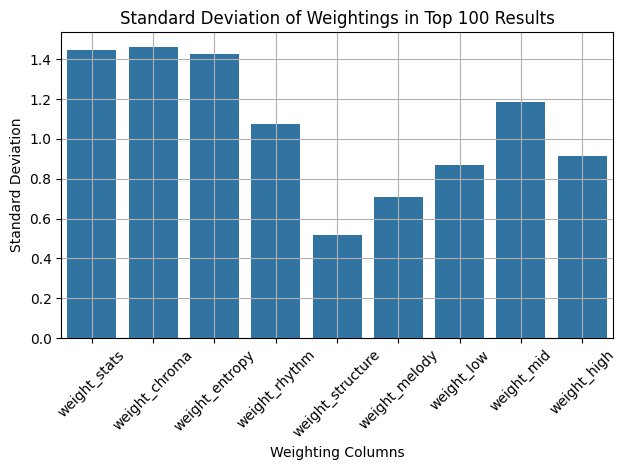

In [ ]:
top_100_sampled_results = uniform_sampled_df.nlargest(100, "accuracy")
weight_cols = [col for col in results_df.columns if "weight" in col]
weight_spread = top_100_sampled_results[weight_cols].std().to_dict()

sns.barplot(
    x=list(weight_spread.keys()),
    y=list(weight_spread.values())
)
plt.title("Standard Deviation of Weightings in Top 100 Results")
plt.xlabel("Weighting Columns")
plt.ylabel("Standard Deviation")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

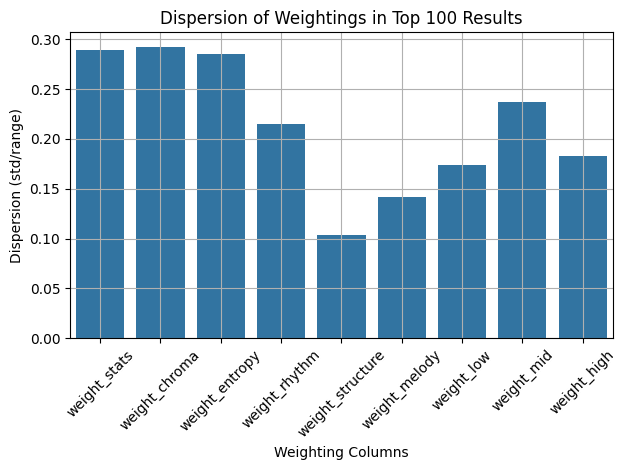

In [ ]:
weight_dispersion = (top_100_sampled_results[weight_cols].std()/5).to_dict()
sns.barplot(
    x=list(weight_dispersion.keys()),
    y=list(weight_dispersion.values())
)
plt.title("Dispersion of Weightings in Top 100 Results")
plt.xlabel("Weighting Columns")
plt.ylabel("Dispersion (std/range)")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()

A dispersion value around 0.29 is expected from uniform random distribution which could mean that stats, chroma and entropy weight values are as consistent as random sampling which is backed up by their weak correlation with accuracy scores. 

Structure weights have the lowest dispersion which combined with their correlation with margin descriptor values could mean it’s a useful feature for increasing the gap by which similarity is taken and therefore is more consistent amongst the best performing weights.

Otherwise the remaining weights all hover between 0.15 and 0.25 roughly meaning their selection is mor meaningful than random sampling.

Next histograms are reproduced to serve as a comparison to the initial plot which accounted for the whole dataset.


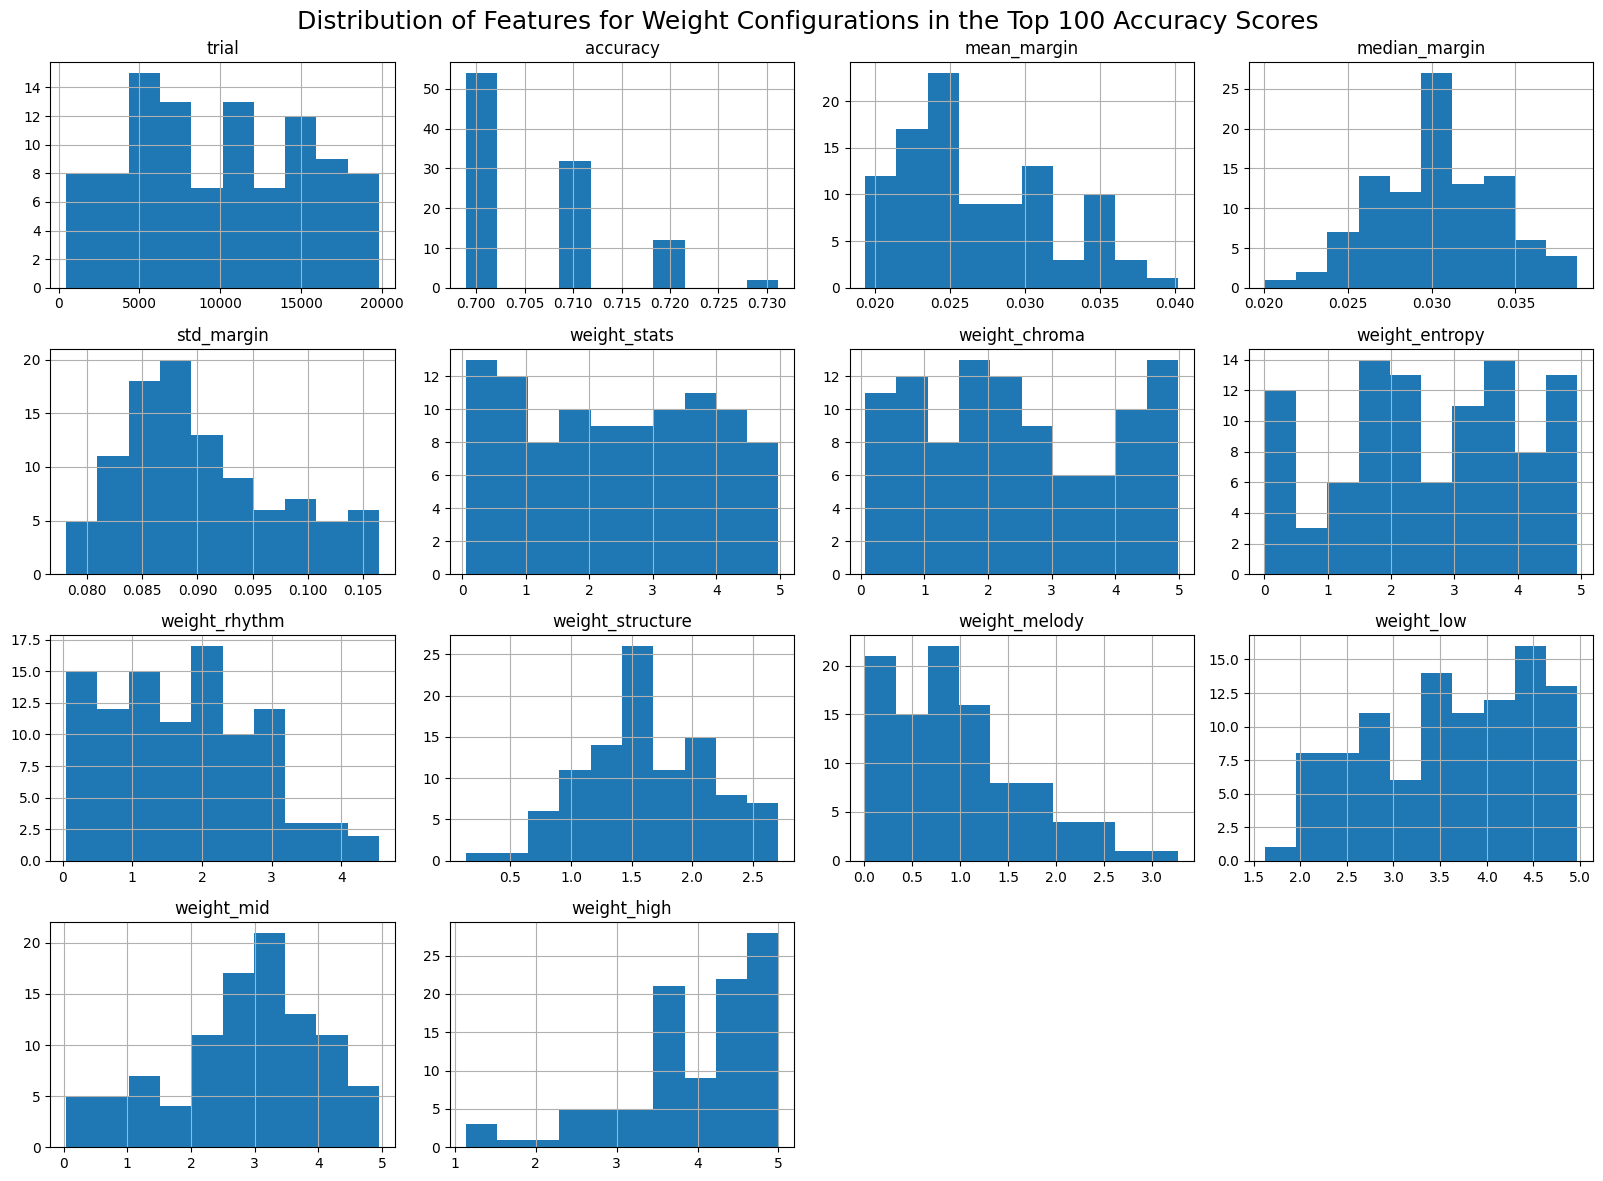

In [ ]:
top_100_sampled_results.hist(
    bins=10,
    figsize=(16, 12),
    layout=(-1, 4)
)

plt.suptitle("Distribution of Features for Weight Configurations in the Top 100 Accuracy Scores", fontsize=18)
plt.tight_layout()
plt.show()

Here the high dispersion values on stats, chroma and entropy are corroborated with histogram shapes that resemble random uniform sampling more than the other weightings.

Insights from correlation with accuracy are backed up here with negative skew on high register weights and a positive skew on melody. Other features seem to show a normal distribution which would suggest that optimal configurations do exist beyond random sampling and cluster around specific values.


Margin values are returned to on these selected best weights.


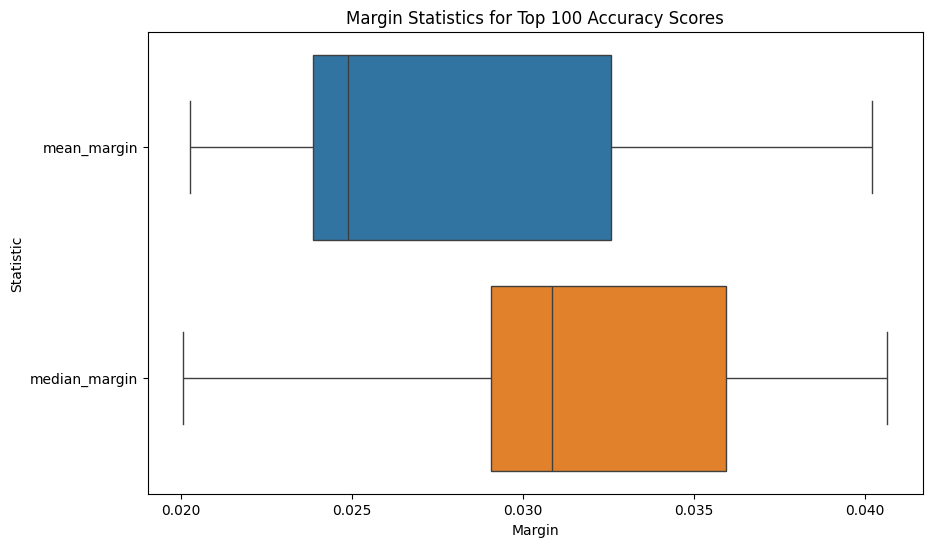

In [53]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=top_100_results[["mean_margin", "median_margin"]],
    orient="h"
)

plt.xlabel("Margin")
plt.ylabel("Statistic")
plt.title("Margin Statistics for Top 100 Accuracy Scores")

plt.show()

Compared to the total result set margin values have increased slightly here indicating that on average the better performing configurations had produced more disparate similarity scores.

## The Best Configuration and Conclusion

The aim of this notebook was to explore the result space and give confidence in selecting the best weight configuration. As such, the best weighting is plotted below:

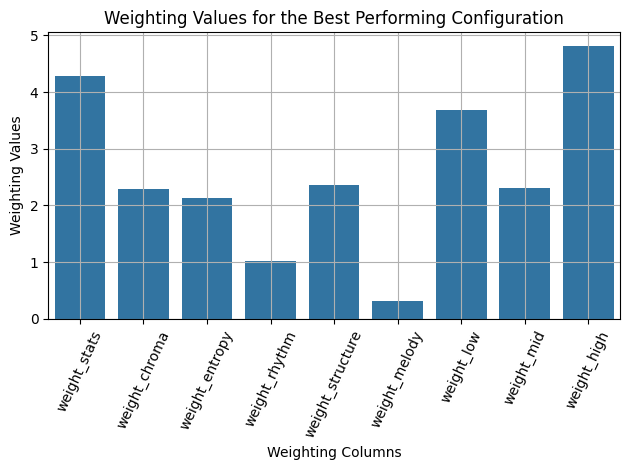

In [41]:
results_df.head(1)
weight_cols = [col for col in results_df.columns if col.startswith("weight_")]
sns.barplot(
    x=results_df[weight_cols].head(1).columns,
    y=results_df[weight_cols].head(1).values.flatten()
)
plt.xlabel("Weighting Columns")
plt.ylabel("Weighting Values")
plt.title("Weighting Values for the Best Performing Configuration")

plt.xticks(rotation=65)
plt.grid()
plt.tight_layout()
plt.show()

The best performing configuration's weight values are backed up by insights from this notebook. Namely, melody is counterproductive to scoring accuracy and is such weighted low whereas the three register values have the highest values. I would also note that stats is the second highest weight here but that is likely largely irrelevant as insight suggests that stats, chroma and entropy have little impact on performance.


With that the project can move forward with this weight configuration selected in good confidence that the produced mapping will be of value. It could be questioned whether feature groups who have been shown to be counterproductive or less impactful should be included at all, but these are left in since as part of the tool the user will be able to select custom weightings.
